In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML_Notebooks/ML_Algorithms/Datasets/data.csv')

In [ ]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [ ]:
X = df.iloc[:, 0:3]
y = df.iloc[:, -1]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 20)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr = LinearRegression()

In [ ]:
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
residue = y_test - y_pred

In [ ]:
# assumption1, linear relationship between i/p and ouput variables

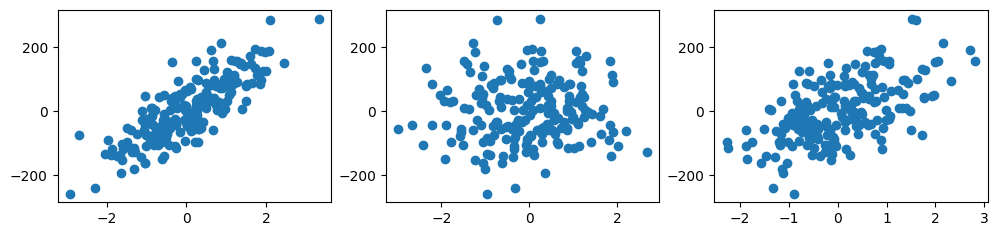

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols= 3, figsize = (12, 2.5))
ax1.scatter(df['feature1'], df['target'])
ax2.scatter(df['feature2'], df['target'])
ax3.scatter(df['feature3'], df['target'])

In [ ]:
# 2. Multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []
for i in range(X_train.shape[1]):
  vif.append(variance_inflation_factor(X_train, i))

In [ ]:
pd.DataFrame({'vif': vif}, index = df.columns[0:3])

,vif
feature1,1.005033
feature2,1.017442
feature3,1.017416


<Axes: >

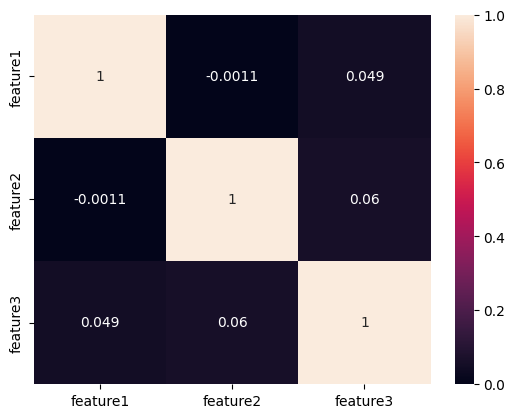

In [ ]:
# Another technique is to use correlation
sns.heatmap(df.iloc[:,0:3].corr(), annot = True)

<Axes: xlabel='target', ylabel='Density'>

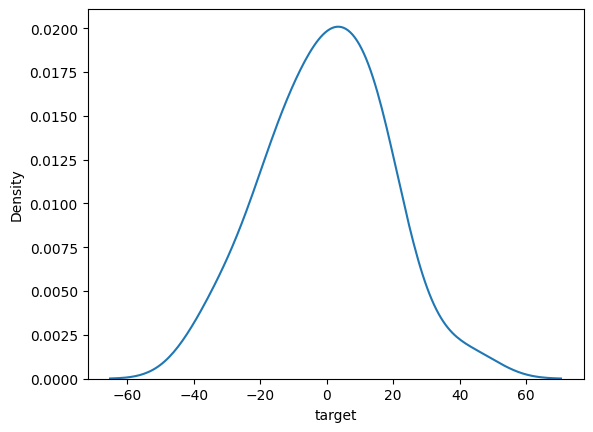

In [ ]:
#3. Residuals normal
sns.kdeplot(data = residue)

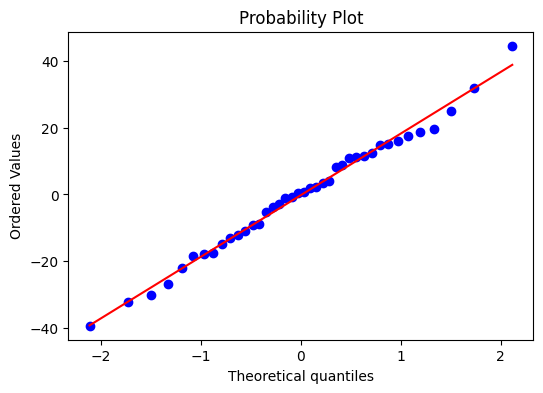

In [ ]:
# qq plot
import scipy as sp

fig, ax = plt.subplots(figsize = (6, 4))
sp.stats.probplot(residue, plot = ax, fit = True)
plt.show()

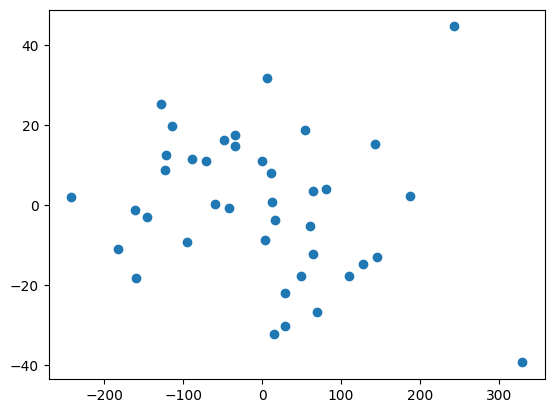

In [ ]:
# 4.Homoescnadicity
plt.scatter(y_pred, residue)

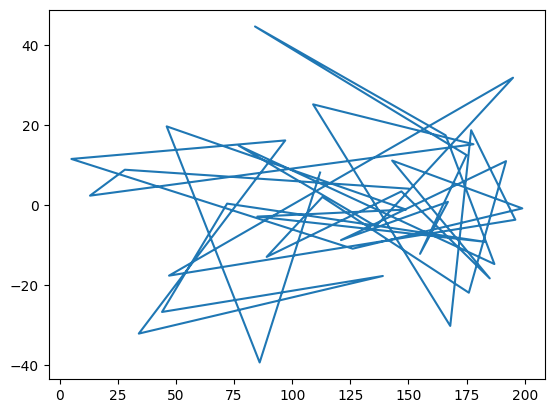

In [ ]:
# no autocorrelation
plt.plot(residue)